In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "olafkrastovski/handwritten-digits-0-9"
)

print(os.listdir(path))

C:\Users\yudhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [3]:
X = []
y = []

for digit in range(10):
    folder = os.path.join(path, str(digit))
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        img = Image.open(img_path).convert("L")
        img = img.resize((28, 28))
        img = np.array(img)

        X.append(img)
        y.append(digit)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21555, 28, 28)
y shape: (21555,)


In [4]:
X = X.reshape(X.shape[0], 28 * 28)
X = X / 255.0

In [5]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=10)

print("y after one-hot:", y.shape)

y after one-hot: (21555, 10)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (17244, 784)
X_test: (4311, 784)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

C:\Users\yudhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1350 - loss: 2.2965 - val_accuracy: 0.1995 - val_loss: 2.2522
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2090 - loss: 2.1859 - val_accuracy: 0.2673 - val_loss: 2.1227
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2681 - loss: 2.0689 - val_accuracy: 0.3613 - val_loss: 1.9970
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3286 - loss: 1.9564 - val_accuracy: 0.3155 - val_loss: 1.9618
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3507 - loss: 1.8977 - val_accuracy: 0.3703 - val_loss: 1.9233
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4071 - loss: 1.8056 - val_accuracy: 0.4335 - val_loss: 1.7861
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4282 - loss: 1.7508 - val_accuracy: 0.4413 - val_loss: 1.7597
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4526 - loss: 1.6986 - val_accuracy: 0.

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4591 - loss: 1.6348
Test Loss: 1.6347599029541016
Test Accuracy: 0.4590582251548767


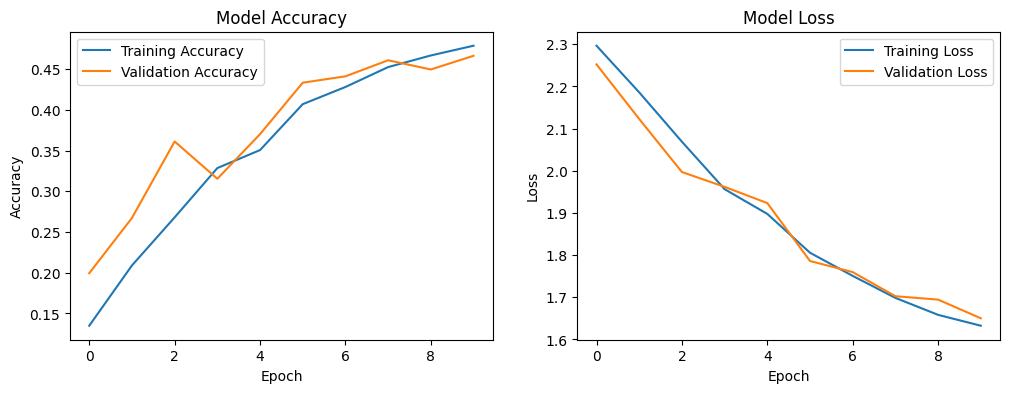

In [11]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


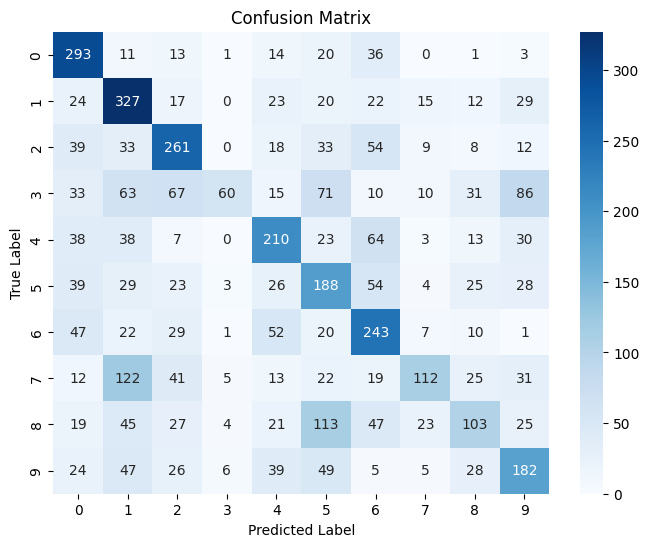

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.52      0.75      0.61       392
           1       0.44      0.67      0.53       489
           2       0.51      0.56      0.53       467
           3       0.75      0.13      0.23       446
           4       0.49      0.49      0.49       426
           5       0.34      0.45      0.38       419
           6       0.44      0.56      0.49       432
           7       0.60      0.28      0.38       402
           8       0.40      0.24      0.30       427
           9       0.43      0.44      0.43       411

    accuracy                           0.46      4311
   macro avg       0.49      0.46      0.44      4311
weighted avg       0.49      0.46      0.44      4311

